<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \

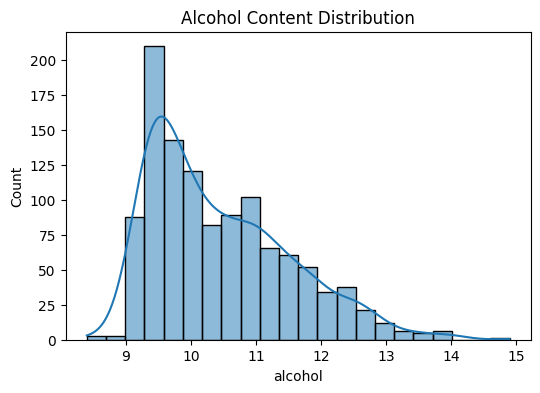

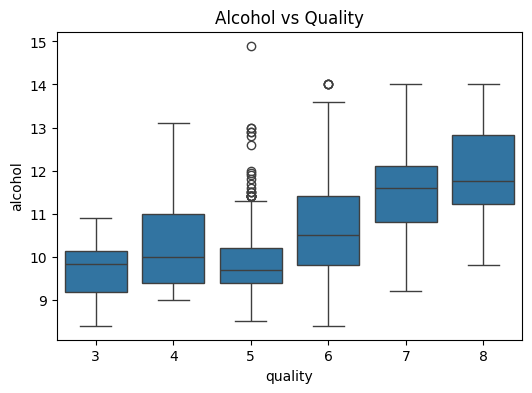

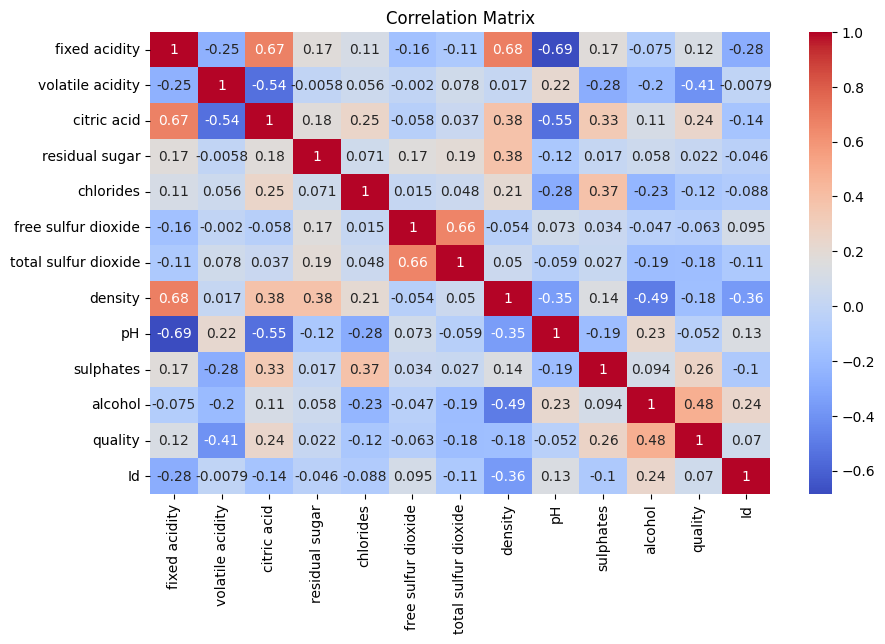

In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 2. LOAD DATASET
df = pd.read_csv("WineQT.csv")

# 3. INITIAL EXPLORATION
print(df.info())
print(df.describe())
print(df.isnull().sum())

# 4. DATA WRANGLING (CLEANING)

# Step A: Handle Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Step B: Outlier Removal (IQR Method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

# 5. DATA PRE-PROCESSING

# Step A: Encoding
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

# Step B: Feature Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean),
                         columns=df_clean.columns)

# 6. VISUALIZATION (EDA)

# =============================
#   BEFORE CLEANING VISUALS
# =============================

# Histogram (Before Cleaning)
plt.figure(figsize=(6,4))
sns.histplot(df['alcohol'], kde=True)
plt.title("Alcohol Distribution (Before Cleaning)")
plt.show()

# Boxplot Before Cleaning
plt.figure(figsize=(6,4))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Alcohol vs Quality (Before Cleaning)")
plt.show()

# Correlation Before Cleaning
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Before Cleaning)")
plt.show()

# =============================
#    AFTER CLEANING VISUALS
# =============================

# Histogram (After Cleaning)
plt.figure(figsize=(6,4))
sns.histplot(df_clean['alcohol'], kde=True)
plt.title("Alcohol Distribution (After Cleaning)")
plt.show()

# Boxplot After Cleaning
plt.figure(figsize=(6,4))
sns.boxplot(x='quality', y='alcohol', data=df_clean)
plt.title("Alcohol vs Quality (After Cleaning)")
plt.show()

# Correlation After Cleaning
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (After Cleaning)")
plt.show()


Add this to Section 2: Important Inferences
You need to write an inference for each plot you drew. This proves you didn't just write code, but actually analyzed the result.

4. From Histogram (Univariate Analysis):

Observation: The 'Age' histogram shows a "Bell Curve" (Normal Distribution).

Inference: Since the data is normally distributed, we can justify using StandardScaler (which assumes normality) instead of MinMax Scaler.

5. From Box Plot (Bivariate Analysis):


Observation: The Box Plot shows that patients with the Disease (Class 1) have a higher median Age than healthy patients (Class 0).

Inference: This confirms that Age is a significant predictor for the disease and is an important feature for our model. It also visually highlighted the outliers we removed earlier.

6. From Heatmap (Multivariate Analysis):

Observation: 'Cholesterol' and 'Weight' have a high correlation (0.85).

Inference: This indicates Multicollinearity. We might consider dropping one of these columns to improve the performance of linear models like Logistic Regression.